# V1_col_7_4 Functional Correlation Analysis

这个 notebook 使用 `microns_phase3.nda` / DataJoint 访问 functional data，并读取已经筛选出的 **V1 column 126 个功能配准神经元**；随后选取 `session=7, scan_idx=4` 的这些神经元 `nda.Activity.trace`，计算 empirical functional correlation matrix 及其 eigenspectrum。

输出文件会保存到当前工作目录下的 `outputs_v1_col_7_4/functional_correlation/2026-05-03/`。


In [1]:
from pathlib import Path
import os
import pickle

import numpy as np
import pandas as pd
import datajoint as dj
import matplotlib.pyplot as plt
import seaborn as sns

from microns_phase3 import nda

pd.set_option("display.max_columns", 100)
sns.set_theme(style="white", context="notebook")

SESSION = 7
SCAN_IDX = 4
SCAN_KEY = {"session": SESSION, "scan_idx": SCAN_IDX}

WORKDIR = Path.cwd()
if not (WORKDIR / "outputs_v1_col_7_4").exists() and (WORKDIR.parent / "outputs_v1_col_7_4").exists():
    WORKDIR = WORKDIR.parent
DATA_DIR_CANDIDATES = [
    WORKDIR / "functional data access and analysis",
    WORKDIR / "Functional data access and analysis",
    WORKDIR,
]
OUTDIR = WORKDIR / "outputs_v1_col_7_4"
RUN_DATE = "2026-05-03"
FUNCTIONAL_BASE_OUTDIR = OUTDIR / "functional_correlation" / RUN_DATE
FUNCTIONAL_EXAMPLE_OUTDIR = FUNCTIONAL_BASE_OUTDIR / "example"
FUNCTIONAL_CORRELATION_OUTDIR = FUNCTIONAL_BASE_OUTDIR / "correlation"
FUNCTIONAL_COUPLING_EIGEN_OUTDIR = FUNCTIONAL_BASE_OUTDIR / "coupling-eigen"
for output_dir in [OUTDIR, FUNCTIONAL_BASE_OUTDIR, FUNCTIONAL_EXAMPLE_OUTDIR, FUNCTIONAL_CORRELATION_OUTDIR, FUNCTIONAL_COUPLING_EIGEN_OUTDIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

UNITS_USED_CSV = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_units_used.csv"
EXPECTED_V1_COLUMN_UNITS = 126
SAVE_PAIRWISE_LONG_TABLE = True  # 126 个神经元只有 7,875 对，保存 long table 很轻量。

print("Working directory:", WORKDIR)
print("Output root:", OUTDIR)
print("Functional output directory:", FUNCTIONAL_BASE_OUTDIR)
print("Functional example directory:", FUNCTIONAL_EXAMPLE_OUTDIR)
print("Functional correlation directory:", FUNCTIONAL_CORRELATION_OUTDIR)
print("Functional coupling/eigen directory:", FUNCTIONAL_COUPLING_EIGEN_OUTDIR)
print("DataJoint config host:", dj.config.get("database.host"))





Connecting root@database:3306
Working directory: /notebooks/workspace
Output root: /notebooks/workspace/outputs_v1_col_7_4
Functional output directory: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03
Functional example directory: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/example
Functional correlation directory: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation
Functional coupling/eigen directory: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen
DataJoint config host: database


## 1. 确认 DataJoint 中的 scan 和 unit 数量

In [2]:
scan_rel = nda.Scan & SCAN_KEY
unit_rel = nda.ScanUnit & SCAN_KEY
activity_rel = nda.Activity & SCAN_KEY

print("Scan rows:", len(scan_rel))
print("ScanUnit rows:", len(unit_rel))
print("Activity rows:", len(activity_rel))
display(scan_rel)



Scan rows: 1
ScanUnit rows: 12675
Activity rows: 12675


session Session ID,scan_idx Scan ID,nframes number of frames per scan,nfields number of fields per scan,fps frames per second (Hz)
7,4,40000,8,6.3009


## 2. 读取已经筛选出的 V1 column 神经元数据

代码会优先在 `functional data access and analysis/` 文件夹中搜索 `.pkl/.csv/.parquet/.feather/.txt` 表格，文件名中带有 `v1`、`column`、`126` 的候选会排在最前。

理想输入表包含 `session`、`scan_idx`、`unit_id`。如果你的文件只有 126 个 `unit_id`，notebook 会默认这些 unit 属于 `session=7, scan_idx=4`。为了避免误用全量 coregistration 数据，这里不会自动退回到 CAVE 的 5625 个 matched units。

In [3]:
def _load_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix in {".pkl", ".pickle"}:
        with open(path, "rb") as f:
            obj = pickle.load(f)
        if isinstance(obj, pd.DataFrame):
            return obj
        if isinstance(obj, (list, tuple, set, np.ndarray, pd.Series)):
            return pd.DataFrame({"unit_id": list(obj)})
        if isinstance(obj, dict):
            # Common cases: {"unit_id": [...]}, {"unit_ids": [...]}, or a dataframe-like dict.
            if "unit_ids" in obj and "unit_id" not in obj:
                return pd.DataFrame({"unit_id": obj["unit_ids"]})
            return pd.DataFrame(obj)
        return pd.DataFrame(obj)
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix == ".feather":
        return pd.read_feather(path)
    if suffix == ".txt":
        values = [line.strip() for line in path.read_text().splitlines() if line.strip()]
        return pd.DataFrame({"unit_id": values})
    raise ValueError(f"Unsupported file type: {path}")


def _normalize_unit_table(df: pd.DataFrame):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    # Accept a few likely unit-id names from manual exports.
    rename_candidates = {
        "unit_ids": "unit_id",
        "unit": "unit_id",
        "functional_unit_id": "unit_id",
        "scan_unit_id": "unit_id",
    }
    for old, new in rename_candidates.items():
        if old in df.columns and new not in df.columns:
            df = df.rename(columns={old: new})

    if "unit_id" not in df.columns:
        return None

    if "session" not in df.columns:
        df["session"] = SESSION
    if "scan_idx" not in df.columns:
        df["scan_idx"] = SCAN_IDX

    df = df.dropna(subset=["unit_id"]).copy()
    df["session"] = df["session"].astype(int)
    df["scan_idx"] = df["scan_idx"].astype(int)
    df["unit_id"] = df["unit_id"].astype(int)
    return df


def find_v1_column_unit_table():
    patterns = ["*.pkl", "*.pickle", "*.csv", "*.parquet", "*.feather", "*.txt"]
    candidates = []
    for data_dir in DATA_DIR_CANDIDATES:
        if not data_dir.exists():
            continue
        for pattern in patterns:
            candidates.extend(data_dir.rglob(pattern))

    def score(path: Path) -> int:
        name = path.name.lower()
        parent = str(path.parent).lower()
        text = name + " " + parent
        strong = ["v1", "column", "126", "session7", "scan4", "s7", "scan_4"]
        weak = ["coreg", "filtered", "neuron", "functional", "unit", "max_num_scan", "ext", "exc"]
        return 10 * sum(k in text for k in strong) + sum(k in text for k in weak)

    for path in sorted(set(candidates), key=lambda p: (-score(p), len(str(p)))):
        try:
            raw = _load_table(path)
            df = _normalize_unit_table(raw)
        except Exception as exc:
            print(f"Skip {path}: {exc}")
            continue
        if df is None:
            print(f"Skip {path.name}: missing unit_id column")
            continue
        n_this_scan = df.query("session == @SESSION and scan_idx == @SCAN_IDX")["unit_id"].nunique()
        print(f"Candidate {path}: {n_this_scan} unique units for session={SESSION}, scan_idx={SCAN_IDX}")
        if n_this_scan == EXPECTED_V1_COLUMN_UNITS:
            print(f"Loaded V1 column unit table: {path}")
            return df, path

    return None, None


df_coreg_filtered, source_path = find_v1_column_unit_table()

if df_coreg_filtered is None:
    raise FileNotFoundError(
        f"没有找到包含 {EXPECTED_V1_COLUMN_UNITS} 个 V1 column unit_id 的本地文件。"
        "请把你筛选出的 V1 column 神经元表放到 'functional data access and analysis/' 文件夹，"
        "或放在当前目录；文件至少需要一列 unit_id。"
    )

print("Source:", source_path)
print("Shape:", df_coreg_filtered.shape)
display(df_coreg_filtered.head())



Candidate /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_units_used.csv: 126 unique units for session=7, scan_idx=4
Loaded V1 column unit table: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_units_used.csv
Source: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_units_used.csv
Shape: (126, 20)


,session,scan_idx,unit_id,id_ref,created_ref,valid_ref,volume,pt_supervoxel_id,pt_root_id,id,created,valid,target_id,field,residual,score,pt_position,bb_start_position,bb_end_position,target_id_ext
0,7,4,2158,292684,2020-09-28 22:45:19.428363+00:00,True,372.53873,91134396396288966,864691134950156796,50009,2024-12-18 19:02:46.471557+00:00,True,292684,2,10.304643,1.758449,[192032 112224 20746],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292684
1,7,4,2162,292889,2020-09-28 22:44:27.240567+00:00,True,254.00066,91134465250137874,864691136126503206,50013,2024-12-18 19:02:46.473745+00:00,True,292889,2,3.482782,8.972762,[191888 112464 21903],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292889
2,7,4,2196,292666,2020-09-28 22:44:02.529861+00:00,True,209.28528,90501215137650063,864691135757002450,50042,2024-12-18 19:02:46.489799+00:00,True,292666,2,13.983134,-3.248180,[187104 112880 20725],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292666
3,7,4,2197,292646,2020-09-28 22:45:13.921913+00:00,True,345.55234,89868446128941331,864691135738969220,50043,2024-12-18 19:02:46.490335+00:00,True,292646,2,6.281342,5.161610,[182528 117344 20379],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292646
4,7,4,2199,292728,2020-09-28 22:45:05.946027+00:00,True,318.60342,90360615155179836,864691136058646488,50045,2024-12-18 19:02:46.491415+00:00,True,292728,2,1.925723,8.506238,[186096 114176 21111],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292728


In [4]:
# Deliberately no CAVE fallback here.
# The CAVE coregistration table contains thousands of matched units for session7scan4;
# this analysis should use only your preselected 126 V1 column neurons.



## 3. 选取 session 7 scan 4 的 126 个 V1 column 神经元

In [5]:
df_session_scan = (
    df_coreg_filtered
    .query("session == @SESSION and scan_idx == @SCAN_IDX")
    .copy()
)

# Keep one row per functional unit. If the source table contains EM ids or V1 column metadata,
# they are preserved in df_units for downstream merging.
df_units = (
    df_session_scan
    .drop_duplicates(subset=["session", "scan_idx", "unit_id"])
    .sort_values("unit_id")
    .reset_index(drop=True)
)

unit_ids = df_units["unit_id"].astype(int).tolist()
print(f"V1 column units in session {SESSION}, scan {SCAN_IDX}: {len(unit_ids)}")
display(df_units.head())

if len(unit_ids) != EXPECTED_V1_COLUMN_UNITS:
    raise ValueError(
        f"Expected {EXPECTED_V1_COLUMN_UNITS} V1 column units, but found {len(unit_ids)}. "
        "Please check that the loaded file is your manually selected V1 column table."
    )



V1 column units in session 7, scan 4: 126


,session,scan_idx,unit_id,id_ref,created_ref,valid_ref,volume,pt_supervoxel_id,pt_root_id,id,created,valid,target_id,field,residual,score,pt_position,bb_start_position,bb_end_position,target_id_ext
0,7,4,2158,292684,2020-09-28 22:45:19.428363+00:00,True,372.53873,91134396396288966,864691134950156796,50009,2024-12-18 19:02:46.471557+00:00,True,292684,2,10.304643,1.758449,[192032 112224 20746],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292684
1,7,4,2162,292889,2020-09-28 22:44:27.240567+00:00,True,254.00066,91134465250137874,864691136126503206,50013,2024-12-18 19:02:46.473745+00:00,True,292889,2,3.482782,8.972762,[191888 112464 21903],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292889
2,7,4,2196,292666,2020-09-28 22:44:02.529861+00:00,True,209.28528,90501215137650063,864691135757002450,50042,2024-12-18 19:02:46.489799+00:00,True,292666,2,13.983134,-3.248180,[187104 112880 20725],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292666
3,7,4,2197,292646,2020-09-28 22:45:13.921913+00:00,True,345.55234,89868446128941331,864691135738969220,50043,2024-12-18 19:02:46.490335+00:00,True,292646,2,6.281342,5.161610,[182528 117344 20379],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292646
4,7,4,2199,292728,2020-09-28 22:45:05.946027+00:00,True,318.60342,90360615155179836,864691136058646488,50045,2024-12-18 19:02:46.491415+00:00,True,292728,2,1.925723,8.506238,[186096 114176 21111],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292728


## 4. 用 DataJoint 读取 activity traces

这里使用 `nda.Activity.trace`，也就是 spike extraction 后的 activity trace。若要改成原始 calcium fluorescence，可通过 `nda.ScanUnit` 关联 `nda.Fluorescence` 获取 `trace`。

In [6]:
selected_keys = [{"session": SESSION, "scan_idx": SCAN_IDX, "unit_id": int(u)} for u in unit_ids]
selected_activity = nda.Activity & selected_keys

print("Requested units:", len(selected_keys))
print("Activity traces found:", len(selected_activity))

activity_records = selected_activity.fetch("KEY", "trace", order_by="unit_id")
keys, traces = activity_records[0], activity_records[1]
activity_unit_ids = np.array([k["unit_id"] for k in keys], dtype=int)

trace_lengths = np.array([len(np.asarray(t).squeeze()) for t in traces])
print("Trace length summary:")
print(pd.Series(trace_lengths).describe())

min_len = int(trace_lengths.min())
trace_matrix = np.vstack([np.asarray(t).squeeze()[:min_len] for t in traces])
print("Trace matrix shape (units x frames):", trace_matrix.shape)

# Save the exact units used.
used_units = pd.DataFrame(keys).merge(df_units, on=["session", "scan_idx", "unit_id"], how="left")
used_units.to_csv(UNITS_USED_CSV, index=False)
display(used_units.head())



Requested units: 126
Activity traces found: 126


Trace length summary:
count      126.0
mean     40000.0
std          0.0
min      40000.0
25%      40000.0
50%      40000.0
75%      40000.0
max      40000.0
dtype: float64
Trace matrix shape (units x frames): (126, 40000)


,session,scan_idx,unit_id,id_ref,created_ref,valid_ref,volume,pt_supervoxel_id,pt_root_id,id,created,valid,target_id,field,residual,score,pt_position,bb_start_position,bb_end_position,target_id_ext
0,7,4,2158,292684,2020-09-28 22:45:19.428363+00:00,True,372.53873,91134396396288966,864691134950156796,50009,2024-12-18 19:02:46.471557+00:00,True,292684,2,10.304643,1.758449,[192032 112224 20746],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292684
1,7,4,2162,292889,2020-09-28 22:44:27.240567+00:00,True,254.00066,91134465250137874,864691136126503206,50013,2024-12-18 19:02:46.473745+00:00,True,292889,2,3.482782,8.972762,[191888 112464 21903],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292889
2,7,4,2196,292666,2020-09-28 22:44:02.529861+00:00,True,209.28528,90501215137650063,864691135757002450,50042,2024-12-18 19:02:46.489799+00:00,True,292666,2,13.983134,-3.248180,[187104 112880 20725],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292666
3,7,4,2197,292646,2020-09-28 22:45:13.921913+00:00,True,345.55234,89868446128941331,864691135738969220,50043,2024-12-18 19:02:46.490335+00:00,True,292646,2,6.281342,5.161610,[182528 117344 20379],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292646
4,7,4,2199,292728,2020-09-28 22:45:05.946027+00:00,True,318.60342,90360615155179836,864691136058646488,50045,2024-12-18 19:02:46.491415+00:00,True,292728,2,1.925723,8.506238,[186096 114176 21111],[<NA> <NA> <NA>],[<NA> <NA> <NA>],292728


## 5. 计算 correlation matrix

In [7]:
def zscore_rows(x: np.ndarray) -> np.ndarray:
    x = x.astype(float)
    mean = np.nanmean(x, axis=1, keepdims=True)
    std = np.nanstd(x, axis=1, keepdims=True)
    std[std == 0] = np.nan
    return (x - mean) / std

z_traces = zscore_rows(trace_matrix)
valid_rows = np.isfinite(z_traces).all(axis=1)

if not valid_rows.all():
    dropped = activity_unit_ids[~valid_rows]
    print(f"Dropping {len(dropped)} units with non-finite or constant traces:", dropped[:20])

z_traces_valid = z_traces[valid_rows]
valid_unit_ids = activity_unit_ids[valid_rows]

corr = np.corrcoef(z_traces_valid)
corr_df = pd.DataFrame(corr, index=valid_unit_ids, columns=valid_unit_ids)

corr_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_correlation_matrix.csv"
corr_npy = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_correlation_matrix.npy"
corr_df.to_csv(corr_csv)
np.save(corr_npy, corr)

print("Correlation matrix shape:", corr_df.shape)
print("Saved:", corr_csv)
print("Saved:", corr_npy)
display(corr_df.iloc[:10, :10])



Correlation matrix shape: (126, 126)
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_matrix.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_matrix.npy


,2158,2162,2196,2197,2199,2200,2201,2202,2205,2207
2158,1.000000,0.014361,0.026958,0.032843,0.017248,0.041183,0.049235,0.031383,0.029096,0.029760
2162,0.014361,1.000000,0.010116,0.005538,-0.002228,0.012510,0.021536,0.015505,-0.003730,0.054100
2196,0.026958,0.010116,1.000000,0.053288,0.010369,0.035114,0.045281,0.042300,0.007639,0.015551
2197,0.032843,0.005538,0.053288,1.000000,0.013968,0.036463,0.021283,0.021464,0.024085,0.026712
2199,0.017248,-0.002228,0.010369,0.013968,1.000000,0.021659,0.028279,0.033804,0.033090,0.032913
2200,0.041183,0.012510,0.035114,0.036463,0.021659,1.000000,0.037862,0.045042,0.031674,0.036867
2201,0.049235,0.021536,0.045281,0.021283,0.028279,0.037862,1.000000,0.064861,0.028939,0.053265
2202,0.031383,0.015505,0.042300,0.021464,0.033804,0.045042,0.064861,1.000000,0.012072,0.026248
2205,0.029096,-0.003730,0.007639,0.024085,0.033090,0.031674,0.028939,0.012072,1.000000,0.017285
2207,0.029760,0.054100,0.015551,0.026712,0.032913,0.036867,0.053265,0.026248,0.017285,1.000000


## 6. 可视化 correlation matrix 和相关性分布

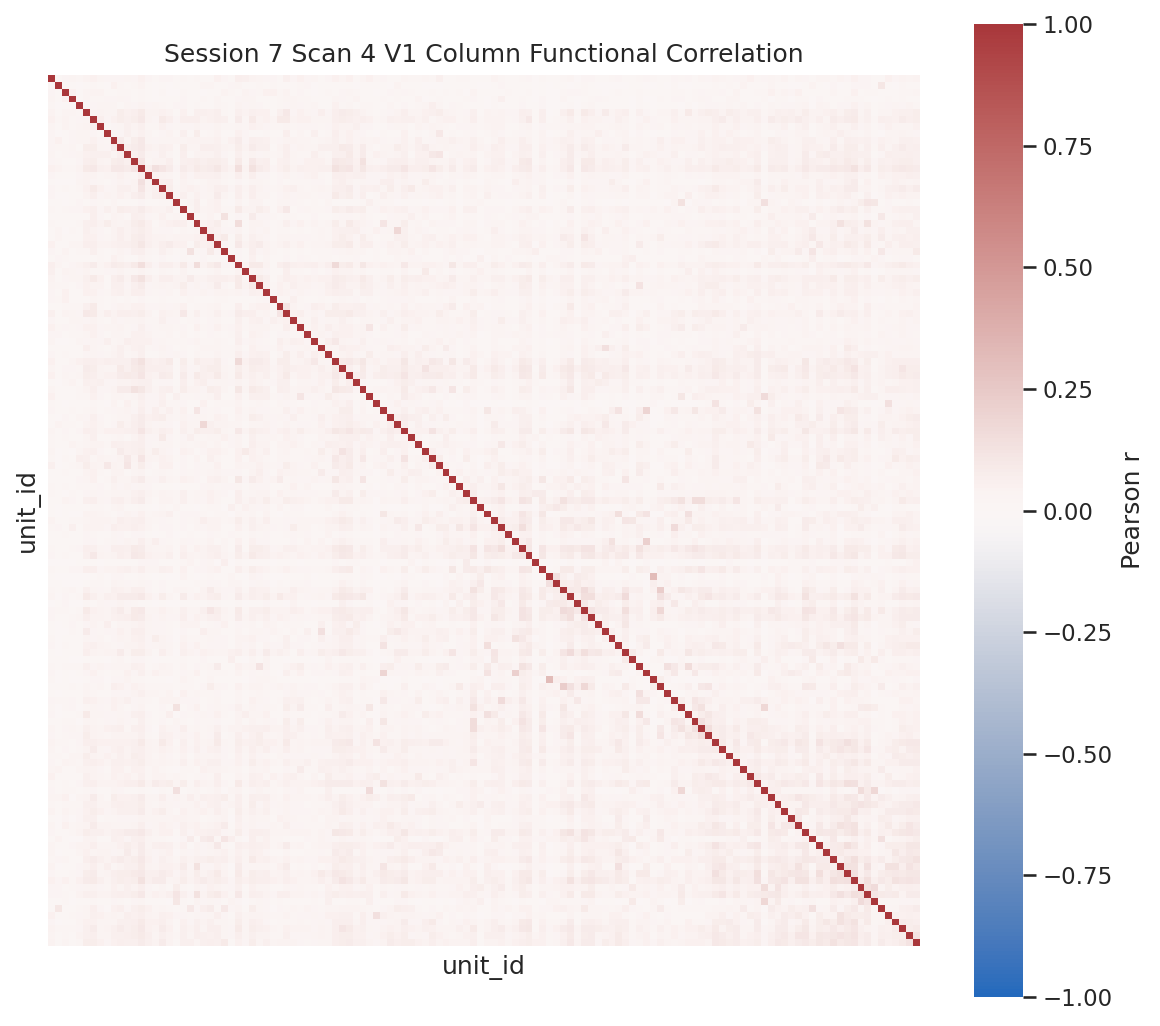

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_heatmap.png


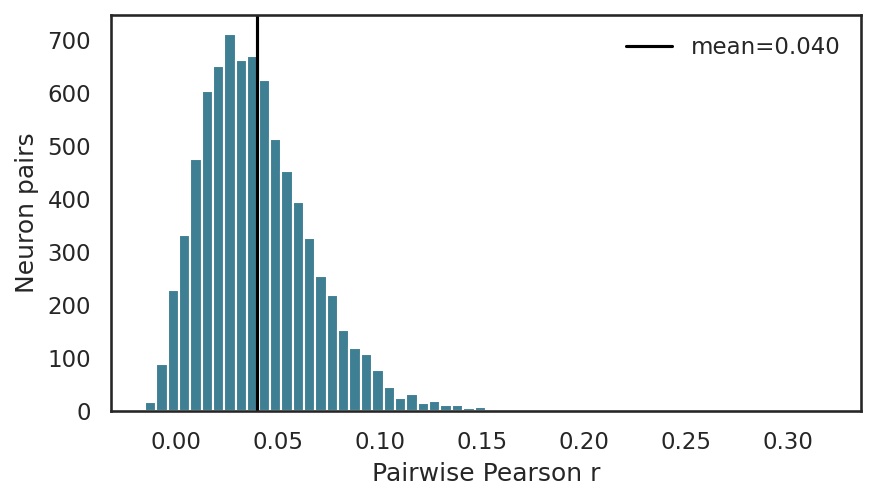

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_activity_correlation_distribution.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 7), dpi=150)
sns.heatmap(
    corr_df,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    square=True,
    cbar_kws={"label": "Pearson r"},
    ax=ax,
)
ax.set_title(f"Session {SESSION} Scan {SCAN_IDX} V1 Column Functional Correlation")
ax.set_xlabel("unit_id")
ax.set_ylabel("unit_id")
fig.tight_layout()
heatmap_path = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_correlation_heatmap.png"
fig.savefig(heatmap_path, bbox_inches="tight")
plt.show()
print("Saved:", heatmap_path)

upper = corr[np.triu_indices_from(corr, k=1)]
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=150)
ax.hist(upper[np.isfinite(upper)], bins=60, color="#3f7f93", edgecolor="white")
ax.axvline(np.nanmean(upper), color="black", lw=1.5, label=f"mean={np.nanmean(upper):.3f}")
ax.set_xlabel("Pairwise Pearson r")
ax.set_ylabel("Neuron pairs")
ax.legend(frameon=False)
fig.tight_layout()
hist_path = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_activity_correlation_distribution.png"
fig.savefig(hist_path, bbox_inches="tight")
plt.show()
print("Saved:", hist_path)



## 7. 可选：保存长表格式 pairwise correlations

如果神经元数量很多，长表会比较大；默认仍保存，便于后续按 `unit_i/unit_j` 合并其他网络或结构信息。

In [9]:
if SAVE_PAIRWISE_LONG_TABLE:
    i_idx, j_idx = np.triu_indices_from(corr, k=1)
    pairwise_corr = pd.DataFrame({
        "unit_i": valid_unit_ids[i_idx],
        "unit_j": valid_unit_ids[j_idx],
        "pearson_r": corr[i_idx, j_idx],
    })
    pairwise_csv = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_pairwise_activity_correlations.csv"
    pairwise_corr.to_csv(pairwise_csv, index=False)
    print("Pairwise rows:", len(pairwise_corr))
    print("Saved:", pairwise_csv)
    display(pairwise_corr.head())
else:
    n = len(valid_unit_ids)
    print(
        f"Skipped pairwise long-table export for {n} units "
        f"({n * (n - 1) // 2:,} pairs). Set SAVE_PAIRWISE_LONG_TABLE = True to save it."
    )



Pairwise rows: 7875
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_pairwise_activity_correlations.csv


,unit_i,unit_j,pearson_r
0,2158,2162,0.014361
1,2158,2196,0.026958
2,2158,2197,0.032843
3,2158,2199,0.017248
4,2158,2200,0.041183


## 8. Functional coupling correlation matrix

这一节只在已经得到的 empirical functional correlation matrix `corr_df` 基础上构造 functional coupling correlation matrix，不再计算 coupling-derived matrix。具体做法是先把 `corr_df` 的对角线置 0 得到 `W_func`，避免自相关 `r=1` 主导结果；然后计算 `W_func.T @ W_func`，表示两个神经元在整个功能相关性 profile 上的相似程度，并用 trace normalization 把总谱质量归一化到神经元数 `N`。


Functional network matrix shape: (126, 126)
Functional coupling correlation shape: (126, 126)
Trace after normalization: 126.00000000000003
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_network_offdiag_matrix.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_network_offdiag_matrix.npy
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_coupling_correlation_matrix.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_coupling_correlation_matrix.npy


unit_id,2158,2162,2196,2197,2199,2200,2201,2202,2205,2207
unit_id,,,,,,,,,,
2158,0.381750,0.123526,0.220163,0.196464,0.269942,0.558487,0.607203,0.390301,0.356667,0.490255
2162,0.123526,0.145016,0.082272,0.075362,0.101106,0.220239,0.252425,0.150968,0.107284,0.226914
2196,0.220163,0.082272,0.210202,0.123672,0.156853,0.361177,0.401737,0.255026,0.211160,0.320794
2197,0.196464,0.075362,0.123672,0.168924,0.144376,0.337496,0.352409,0.236370,0.209195,0.290959
2199,0.269942,0.101106,0.156853,0.144376,0.249511,0.447802,0.476846,0.299939,0.281409,0.374950
2200,0.558487,0.220239,0.361177,0.337496,0.447802,1.098657,1.081773,0.685570,0.627214,0.873283
2201,0.607203,0.252425,0.401737,0.352409,0.476846,1.081773,1.239151,0.726724,0.645779,0.933102
2202,0.390301,0.150968,0.255026,0.236370,0.299939,0.685570,0.726724,0.507014,0.417656,0.607206
2205,0.356667,0.107284,0.211160,0.209195,0.281409,0.627214,0.645779,0.417656,0.461525,0.500907


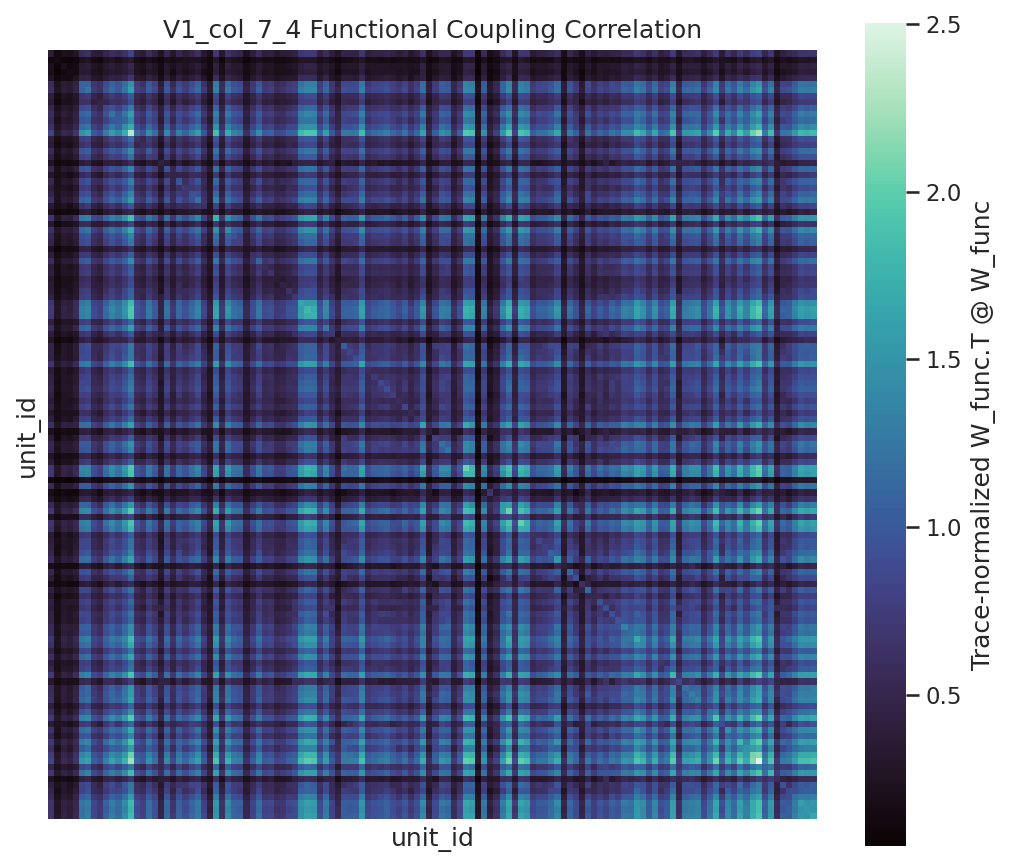

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_coupling_correlation_heatmap.png


In [10]:
functional_corr_df = corr_df.copy().astype(float)
functional_unit_ids = functional_corr_df.index.to_numpy(dtype=int)

W_func_df = functional_corr_df.copy()
np.fill_diagonal(W_func_df.values, 0.0)
W_func_df.index.name = "unit_id"
W_func_df.columns.name = "unit_id"

functional_network_csv = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_network_offdiag_matrix.csv"
functional_network_npy = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_network_offdiag_matrix.npy"
W_func_df.to_csv(functional_network_csv)
np.save(functional_network_npy, W_func_df.to_numpy(dtype=float))

FunctionalCouplingCorrelation = (W_func_df.T @ W_func_df).astype(float)
N_functional_coupling = FunctionalCouplingCorrelation.shape[0]
trace_functional_coupling = float(np.trace(FunctionalCouplingCorrelation.to_numpy(dtype=float)))
if trace_functional_coupling <= 0:
    raise ValueError("Functional coupling correlation trace is zero; cannot trace-normalize matrix.")
FunctionalCouplingCorrelation = FunctionalCouplingCorrelation / trace_functional_coupling * N_functional_coupling
FunctionalCouplingCorrelation.index.name = "unit_id"
FunctionalCouplingCorrelation.columns.name = "unit_id"
FunctionalCouplingCorrelationMatrix = FunctionalCouplingCorrelation.to_numpy(dtype="float64")

functional_coupling_corr_csv = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_coupling_correlation_matrix.csv"
functional_coupling_corr_npy = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_coupling_correlation_matrix.npy"
FunctionalCouplingCorrelation.to_csv(functional_coupling_corr_csv)
np.save(functional_coupling_corr_npy, FunctionalCouplingCorrelationMatrix)

print("Functional network matrix shape:", W_func_df.shape)
print("Functional coupling correlation shape:", FunctionalCouplingCorrelation.shape)
print("Trace after normalization:", np.trace(FunctionalCouplingCorrelationMatrix))
print("Saved:", functional_network_csv)
print("Saved:", functional_network_npy)
print("Saved:", functional_coupling_corr_csv)
print("Saved:", functional_coupling_corr_npy)
display(FunctionalCouplingCorrelation.iloc[:10, :10])

fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
sns.heatmap(
    FunctionalCouplingCorrelation,
    cmap="mako",
    xticklabels=False,
    yticklabels=False,
    square=True,
    cbar_kws={"label": "Trace-normalized W_func.T @ W_func"},
    ax=ax,
)
ax.set_title("V1_col_7_4 Functional Coupling Correlation")
ax.set_xlabel("unit_id")
ax.set_ylabel("unit_id")
fig.tight_layout()
functional_coupling_corr_heatmap = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_coupling_correlation_heatmap.png"
fig.savefig(functional_coupling_corr_heatmap, bbox_inches="tight")
plt.show()
print("Saved:", functional_coupling_corr_heatmap)


## 9. 不同子采样规模下的 functional eigenspectrum

这一节在第 10 节最终 eigenspectrum 之前，沿用结构分析 notebook 中的子采样方法：对矩阵随机抽取不同比例的神经元子集，计算每个子矩阵的 eigenspectrum，并绘制多次抽样的平均谱与标准差范围。这里比较两个矩阵：empirical activity correlation matrix 和第 8 节得到的 functional coupling correlation matrix。


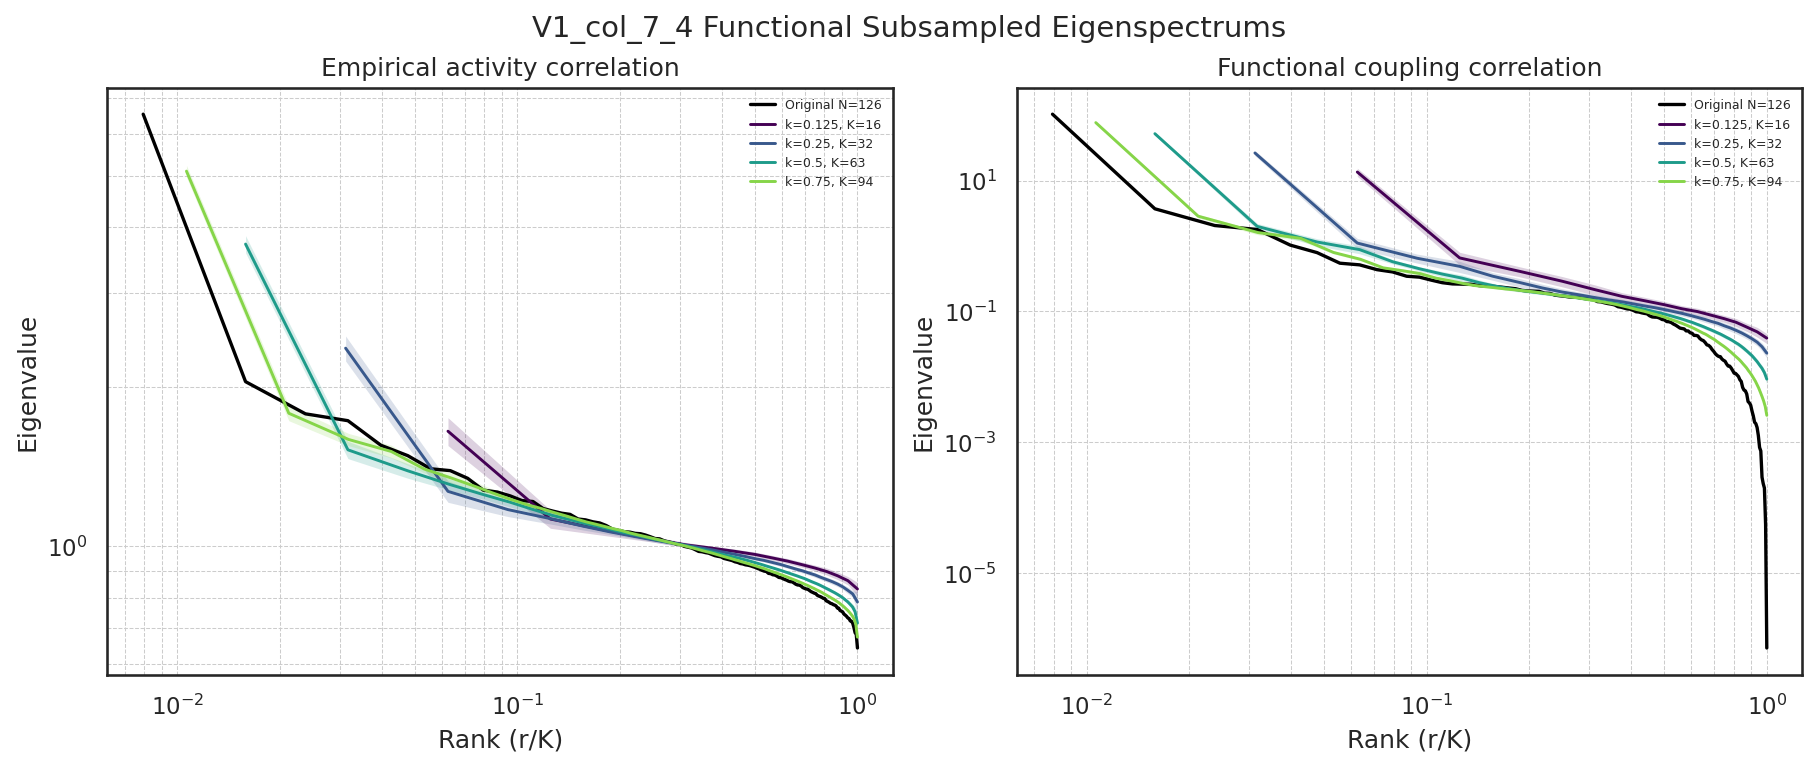

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_subsampled_eigenspectrums.png
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_correlation_subsampled_eigenspectrum.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_coupling_correlation_subsampled_eigenspectrum.csv


,k_fraction,K,rank,rank_normalized,mean_eigenvalue,std_eigenvalue
0,0.125,16,1,0.0625,1.647862,0.099293
1,0.125,16,2,0.1250,1.125620,0.044399
2,0.125,16,3,0.1875,1.067284,0.023210
3,0.125,16,4,0.2500,1.030646,0.012283
4,0.125,16,5,0.3125,1.006272,0.010568


,k_fraction,K,rank,rank_normalized,mean_eigenvalue,std_eigenvalue
0,0.125,16,1,0.0625,13.607677,1.937141
1,0.125,16,2,0.1250,0.659138,0.144660
2,0.125,16,3,0.1875,0.411087,0.071649
3,0.125,16,4,0.2500,0.290277,0.051918
4,0.125,16,5,0.3125,0.215338,0.039046


In [11]:
def get_subsampled_eigenspectrum(matrix: np.ndarray, k_fraction: float, n_iter: int = 50, seed=None):
    """Randomly subsample K = round(N * k_fraction) neurons and average eigenspectrums."""
    matrix = np.asarray(matrix, dtype=float)
    N = matrix.shape[0]
    K = int(np.round(N * k_fraction))
    if K < 2:
        raise ValueError("Subsample size K must be at least 2.")
    rng = np.random.default_rng(seed)
    all_evals = []
    for _ in range(n_iter):
        inds = rng.choice(N, K, replace=False)
        submatrix = matrix[np.ix_(inds, inds)]
        evals = np.linalg.eigvalsh(submatrix)
        all_evals.append(np.sort(evals)[::-1])
    all_evals = np.asarray(all_evals)
    return all_evals.mean(axis=0), all_evals.std(axis=0), all_evals


def plot_subsampled_eigenspectrum(axis, matrix, title, k_fractions, n_iter=50, seed=43):
    matrix = np.asarray(matrix, dtype=float)
    original_evals = np.sort(np.linalg.eigvalsh(matrix))[::-1]
    original_ranks = (np.arange(len(original_evals)) + 1) / len(original_evals)
    original_positive = np.isfinite(original_evals) & (original_evals > 0)
    axis.loglog(
        original_ranks[original_positive],
        original_evals[original_positive],
        color="black",
        linewidth=1.6,
        label="Original N={}".format(matrix.shape[0]),
    )

    colors_sub = plt.cm.viridis(np.linspace(0, 0.82, len(k_fractions)))
    summary_rows = []
    for idx, k_fraction in enumerate(k_fractions):
        mean_evals, std_evals, _ = get_subsampled_eigenspectrum(
            matrix,
            k_fraction=k_fraction,
            n_iter=n_iter,
            seed=seed + idx,
        )
        K = len(mean_evals)
        ranks = (np.arange(K) + 1) / K
        upper = mean_evals + std_evals
        lower = mean_evals - std_evals
        positive = (
            np.isfinite(mean_evals)
            & (mean_evals > 0)
            & np.isfinite(upper)
            & (upper > 0)
        )
        if positive.any():
            safe_lower = np.maximum(lower[positive], np.finfo(float).tiny)
            axis.loglog(
                ranks[positive],
                mean_evals[positive],
                color=colors_sub[idx],
                linewidth=1.4,
                label="k={:.3g}, K={}".format(k_fraction, K),
            )
            axis.fill_between(
                ranks[positive],
                safe_lower,
                upper[positive],
                color=colors_sub[idx],
                alpha=0.18,
                linewidth=0,
            )
        for rank_idx, eigenvalue in enumerate(mean_evals, start=1):
            summary_rows.append({
                "k_fraction": k_fraction,
                "K": K,
                "rank": rank_idx,
                "rank_normalized": rank_idx / K,
                "mean_eigenvalue": eigenvalue,
                "std_eigenvalue": std_evals[rank_idx - 1],
            })

    axis.set_title(title)
    axis.set_xlabel("Rank (r/K)")
    axis.set_ylabel("Eigenvalue")
    axis.grid(True, which="both", linestyle="--", linewidth=0.5)
    axis.legend(frameon=False, fontsize=6)
    return pd.DataFrame(summary_rows)

empirical_corr_matrix = corr_df.to_numpy(dtype=float)
functional_coupling_corr_matrix = FunctionalCouplingCorrelationMatrix

k_fractions = [0.125, 0.25, 0.5, 0.75]
n_iter = 50
subsample_seed = 43

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150, constrained_layout=True)
fig.suptitle("V1_col_7_4 Functional Subsampled Eigenspectrums", fontsize=14)
empirical_subsampled_eigenspectrum_df = plot_subsampled_eigenspectrum(
    axes[0],
    empirical_corr_matrix,
    "Empirical activity correlation",
    k_fractions=k_fractions,
    n_iter=n_iter,
    seed=subsample_seed,
)
functional_coupling_subsampled_eigenspectrum_df = plot_subsampled_eigenspectrum(
    axes[1],
    functional_coupling_corr_matrix,
    "Functional coupling correlation",
    k_fractions=k_fractions,
    n_iter=n_iter,
    seed=subsample_seed + 1000,
)

subsampled_eigenspectrum_png = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_subsampled_eigenspectrums.png"
fig.savefig(subsampled_eigenspectrum_png, bbox_inches="tight")
plt.show()
print("Saved:", subsampled_eigenspectrum_png)

empirical_subsampled_csv = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_activity_correlation_subsampled_eigenspectrum.csv"
functional_coupling_subsampled_csv = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_coupling_correlation_subsampled_eigenspectrum.csv"
empirical_subsampled_eigenspectrum_df.to_csv(empirical_subsampled_csv, index=False)
functional_coupling_subsampled_eigenspectrum_df.to_csv(functional_coupling_subsampled_csv, index=False)
print("Saved:", empirical_subsampled_csv)
print("Saved:", functional_coupling_subsampled_csv)
display(empirical_subsampled_eigenspectrum_df.head())
display(functional_coupling_subsampled_eigenspectrum_df.head())


## 10. Empirical correlation 与 functional coupling correlation 的 eigenspectrum

这一节分别计算并可视化两个矩阵的 eigenspectrum：真实 activity trace 得到的 empirical correlation matrix，以及第 8 节构造出的 functional coupling correlation matrix。这里不生成 coupling-derived correlation。


Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_activity_correlation_eigenspectrum.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_coupling_correlation_eigenspectrum.csv


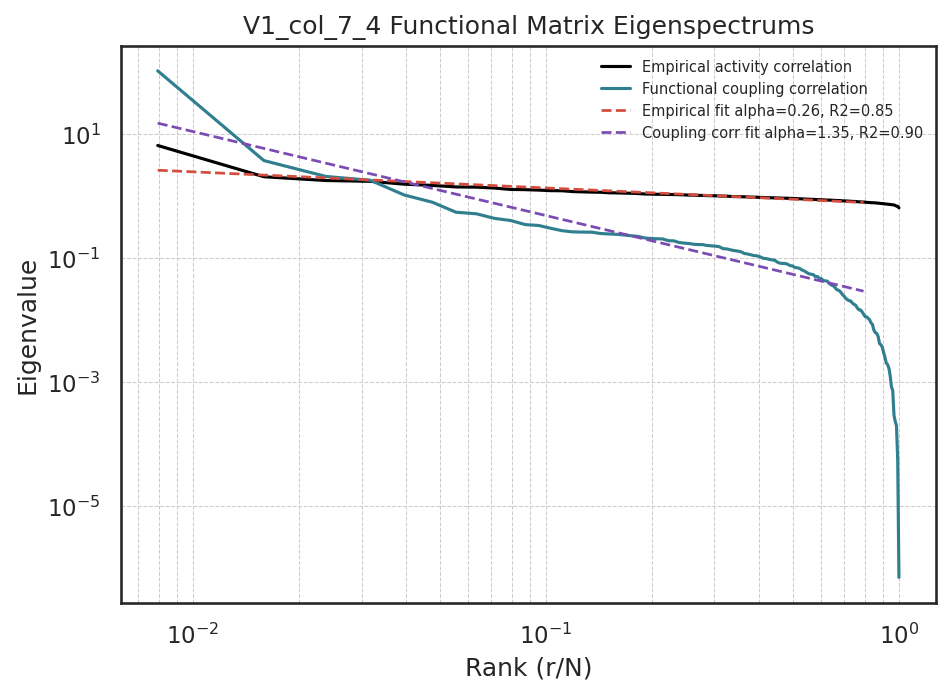

Saved: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/coupling-eigen/V1_col_7_4_functional_correlation_and_coupling_eigenspectrums.png


,rank,rank_normalized,eigenvalue
0,1,0.007937,6.524891
1,2,0.015873,2.043231
2,3,0.023810,1.776919
3,4,0.031746,1.724752
4,5,0.039683,1.550314
5,6,0.047619,1.481808
6,7,0.055556,1.400025
7,8,0.063492,1.388537
8,9,0.071429,1.343001
9,10,0.079365,1.276059


,rank,rank_normalized,eigenvalue
0,1,0.007937,104.386578
1,2,0.015873,3.721844
2,3,0.023810,2.064184
3,4,0.031746,1.796289
4,5,0.039683,1.035662
5,6,0.047619,0.793863
6,7,0.055556,0.547232
7,8,0.063492,0.516252
8,9,0.071429,0.435795
9,10,0.079365,0.402336


In [12]:
def eigenspectrum_desc(matrix: np.ndarray) -> np.ndarray:
    evals = np.linalg.eigvalsh(matrix)
    return np.sort(evals)[::-1]


def fit_power_law_positive(eigenvalues: np.ndarray, num_top_eigenvalues: int = 100):
    evals = np.sort(np.asarray(eigenvalues, dtype=float))[::-1]
    positive_positions = np.flatnonzero(evals > 0)
    n_fit = min(num_top_eigenvalues, len(positive_positions))
    if n_fit < 2:
        return None
    fit_positions = positive_positions[:n_fit]
    top_evals = evals[fit_positions]
    normalized_ranks = (fit_positions + 1) / len(evals)
    log_x = np.log(normalized_ranks)
    log_y = np.log(top_evals)
    slope, intercept = np.polyfit(log_x, log_y, 1)
    fitted_y = np.exp(slope * log_x + intercept)
    r_squared = np.corrcoef(log_x, log_y)[0, 1] ** 2
    return {
        "slope": slope,
        "intercept": intercept,
        "exponent": -slope,
        "r_squared": r_squared,
        "data_x": normalized_ranks,
        "data_y": top_evals,
        "fitted_y": fitted_y,
    }


def save_eigenspectrum_csv(eigenvalues: np.ndarray, output_path: Path):
    ranks = np.arange(1, len(eigenvalues) + 1)
    df = pd.DataFrame({
        "rank": ranks,
        "rank_normalized": ranks / len(eigenvalues),
        "eigenvalue": eigenvalues,
    })
    df.to_csv(output_path, index=False)
    print("Saved:", output_path)
    return df


def plot_positive_eigenvalues(axis, eigenvalues, label, color):
    eigenvalues = np.asarray(eigenvalues, dtype=float)
    ranks = (np.arange(len(eigenvalues)) + 1) / len(eigenvalues)
    positive = np.isfinite(eigenvalues) & (eigenvalues > 0)
    axis.loglog(ranks[positive], eigenvalues[positive], color=color, linewidth=1.5, label=label)

empirical_corr_matrix = corr_df.to_numpy(dtype=float)
empirical_corr_evals = eigenspectrum_desc(empirical_corr_matrix)
functional_coupling_corr_evals = eigenspectrum_desc(FunctionalCouplingCorrelationMatrix)

empirical_eigenspectrum_df = save_eigenspectrum_csv(
    empirical_corr_evals,
    FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_activity_correlation_eigenspectrum.csv",
)
functional_coupling_eigenspectrum_df = save_eigenspectrum_csv(
    functional_coupling_corr_evals,
    FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_coupling_correlation_eigenspectrum.csv",
)

fit_empirical = fit_power_law_positive(empirical_corr_evals, num_top_eigenvalues=100)
fit_functional_coupling = fit_power_law_positive(functional_coupling_corr_evals, num_top_eigenvalues=100)

fig, ax = plt.subplots(figsize=(6.5, 4.8), dpi=150)
plot_positive_eigenvalues(ax, empirical_corr_evals, "Empirical activity correlation", "black")
plot_positive_eigenvalues(ax, functional_coupling_corr_evals, "Functional coupling correlation", "#2f7f8f")

for fit, color, label in [
    (fit_empirical, "#d54b3d", "Empirical fit"),
    (fit_functional_coupling, "#7b4ab2", "Coupling corr fit"),
]:
    if fit is not None:
        ax.loglog(
            fit["data_x"],
            fit["fitted_y"],
            "--",
            color=color,
            linewidth=1.3,
            label="{} alpha={:.2f}, R2={:.2f}".format(label, fit["exponent"], fit["r_squared"]),
        )

ax.set_xlabel("Rank (r/N)")
ax.set_ylabel("Eigenvalue")
ax.set_title("V1_col_7_4 Functional Matrix Eigenspectrums")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
functional_eigenspectrum_png = FUNCTIONAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_functional_correlation_and_coupling_eigenspectrums.png"
fig.savefig(functional_eigenspectrum_png, bbox_inches="tight")
plt.show()
print("Saved:", functional_eigenspectrum_png)

display(empirical_eigenspectrum_df.head(10))
display(functional_coupling_eigenspectrum_df.head(10))
